center_of_mass_windowed:
Derived from the “step settle” workflow, which addressed stray light issues in the acquisition. Some processing steps are redundant but do not interfere with locating the spot in the image, so they have been retained. As the name suggests, this function calculates the center of mass of the spot, applying thresholding to minimize the influence of ghosting artifacts.

analyze_spot:
Rotates the image so that the spot’s full trace is aligned parallel to the x-axis. A local ROI is created around the spot, using center_of_mass_windowed as a starting point. The function first fits a cross section along the x-axis, then adjusts the y-axis position to align with the x-axis fit center. The y-axis is subsequently fitted along this cross section. The fit centers from both axes are used to calculate corrected global centroid coordinates. All fit parameters, including the integrated area under the fit curve are returned.

process_images:
Batch processes all spot images in a parent directory. For each image, it saves the local ROI with cross sections plotted. Horizontal and vertical cross section plots, with fits overlaid, are also saved. Additionally, a CSV file of all fit data is compiled and saved, along with a README explaining the CSV format.

analyze_fwhm:
Uses the CSV generated by process_images to compute the range, average FWHM, and the number of spots, propagating errors from the Gaussian fits.

average_profiles_and_fit: loads all horizontal and vertical profile data saved from spot analysis and averages the intensity traces across all images. It then generates corresponding x-axes, performs Gaussian curve fitting on the averaged horizontal and vertical profiles, and saves both the raw averages and their fitted curves as CSV files and plots. This provides smoothed, representative intensity distributions and their Gaussian approximations for later visualization and analysis.

plot_xy: creates a customizable 2D plot of x–y data with optional fitted line overlay. It allows control over axis limits, labels, title, and figure size, while applying a consistent high-quality style (large Arial font, thick lines, custom ticks, and spines). The plot can be saved as either PNG or SVG depending on user choice, and is displayed interactively after creation.

Set 'parent_dir' to the folder with raw data. 

In [91]:
#requirements
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
import os
import re
import csv
import pandas as pd

In [92]:
def center_of_mass_windowed(image_path, N=50, x1=0, x2=2592, threshold_frac=0.75):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be loaded.")
    image = image.astype(np.float64)

    # threshold image 
    threshold = threshold_frac * np.max(image)
    _, binary = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    binary = binary.astype(np.uint8)

    # find blobs
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
    if num_labels <= 1:
        _, _, _, max_loc = cv2.minMaxLoc(image)
        return max_loc[0]

    # filter blobs by centroid x between x1 and x2
    valid_labels = [
        i for i in range(1, num_labels) 
        if x1 <= centroids[i][0] <= x2
    ]
    if not valid_labels:
        _, _, _, max_loc = cv2.minMaxLoc(image)
        return max_loc[0]

    # find largest valid blob (by area)
    areas = [(i, stats[i, cv2.CC_STAT_AREA]) for i in valid_labels]
    chosen_label = max(areas, key=lambda x: x[1])[0]
    
    # Get initial centroid from the blob
    cx, cy = centroids[chosen_label]
    cx, cy = int(round(cx)), int(round(cy))

    # Define ROI around blob centroid (as before)
    half_N = N // 2
    x_start = max(cx - half_N, 0)
    x_end = min(cx + half_N + 1, image.shape[1])
    y_start = max(cy - half_N, 0)
    y_end = min(cy + half_N + 1, image.shape[0])
    roi = image[y_start:y_end, x_start:x_end]

    # --- New: refine centroid to brightest 4x4 patch ---
    patch_size = 4
    roi_h, roi_w = roi.shape
    max_avg = -1
    best_patch = (0, 0)

    for y in range(roi_h - patch_size + 1):
        for x in range(roi_w - patch_size + 1):
            patch = roi[y:y+patch_size, x:x+patch_size]
            avg_intensity = np.mean(patch)
            if avg_intensity > max_avg:
                max_avg = avg_intensity
                best_patch = (x, y)

    # Compute center of patch in ROI coordinates
    patch_cx = best_patch[0] + patch_size / 2
    patch_cy = best_patch[1] + patch_size / 2

    # Convert to global image coordinates
    cx_refined = x_start + patch_cx
    cy_refined = y_start + patch_cy

    # Convert refined centroid to integers for slicing
    cx_refined_int = int(round(cx_refined))
    cy_refined_int = int(round(cy_refined))

    # Define ROI around refined centroid
    half_N = N // 2
    x_start = max(cx_refined_int - half_N, 0)
    x_end = min(cx_refined_int + half_N + 1, image.shape[1])
    y_start = max(cy_refined_int - half_N, 0)
    y_end = min(cy_refined_int + half_N + 1, image.shape[0])
    roi = image[y_start:y_end, x_start:x_end]


    if np.sum(roi) == 0:
        return cx_refined, cy_refined

    # ROI already defined around cx_refined_int, cy_refined_int
    y_indices, x_indices = np.indices(roi.shape)
    roi_total = np.sum(roi)
    if roi_total == 0:
        return cx_refined, cy_refined

    center_x_roi = np.sum(x_indices * roi) / roi_total
    center_y_roi = np.sum(y_indices * roi) / roi_total

    center_x_img = x_start + center_x_roi
    center_y_img = y_start + center_y_roi

    return cx_refined

In [93]:
def gaussian(x, amp, mean, sigma, offset):
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2)) + offset

In [94]:
def analyze_spot(image_path, angle=0, roi_size=50, threshold_frac=0.75, x1=850, x2=2592):
    # Load image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be loaded.")
    image = image.astype(np.float64)

    #Rotate image angle
    h, w = image.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, -angle, 1.0)  # negative for clockwise
    rotated = cv2.warpAffine(image, M, (w, h))

    #use centroid function to find x
    cx = center_of_mass_windowed(
        image_path, N=roi_size, x1=x1, x2=x2, threshold_frac=threshold_frac
    )
    
    #compute centroid y on rotated image
    threshold = threshold_frac * np.max(rotated)
    _, binary = cv2.threshold(rotated, threshold, 255, cv2.THRESH_BINARY)
    binary = binary.astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)
    if num_labels <= 1:
        _, _, _, max_loc = cv2.minMaxLoc(rotated)
        cy = max_loc[1]
    else:
        chosen_label = min(
            range(1, num_labels), 
            key=lambda i: abs(centroids[i][0] - cx)
        )
        cy = centroids[chosen_label][1]
    cx, cy = int(round(cx)), int(round(cy))

    #Extract ROI around centroid
    half = roi_size // 2
    x_start, x_end = max(cx-half,0), min(cx+half, rotated.shape[1])
    y_start, y_end = max(cy-half,0), min(cy+half, rotated.shape[0])
    roi = rotated[y_start:y_end, x_start:x_end]

    #Local centroid inside ROI
    local_cx = min(cx - x_start, roi.shape[1]-1)
    local_cy = min(cy - y_start, roi.shape[0]-1)

    #Extract horizontal profile and fit Gaussian first
    profile_h = roi[local_cy, :]       # horizontal (row)
    x_vals_h = np.arange(len(profile_h))
    try:
        p0 = [np.max(profile_h)-np.min(profile_h), len(profile_h)/2, 5, np.min(profile_h)]
        popt_h, pcov_h = curve_fit(gaussian, x_vals_h, profile_h, p0=p0)
        perr_h = np.sqrt(np.diag(pcov_h))  # standard errors
    except RuntimeError:
        popt_h = [np.nan]*4
        perr_h = [np.nan]*4

    #extract vertical profile through horizontal Gaussian mean
    local_cx_fit = int(round(popt_h[1]))
    profile_v = roi[:, local_cx_fit]       # vertical (column)
    x_vals_v = np.arange(len(profile_v))
    try:
        p0 = [np.max(profile_v)-np.min(profile_v), len(profile_v)/2, 5, np.min(profile_v)]
        popt_v, pcov_v = curve_fit(gaussian, x_vals_v, profile_v, p0=p0)
        perr_v = np.sqrt(np.diag(pcov_v))
    except RuntimeError:
        popt_v = [np.nan]*4
        perr_v = [np.nan]*4

    #Corrected global centroid
    cx_corrected = cx + (popt_h[1] - half)
    cy_corrected = cy + (popt_v[1] - half)

    #Propagated errors for corrected centroid
    cx_corrected_err = perr_h[1] if not np.isnan(perr_h[1]) else np.nan
    cy_corrected_err = perr_v[1] if not np.isnan(perr_v[1]) else np.nan


    #area under Gaussian fits
    area_h = popt_h[0] * popt_h[2] * np.sqrt(2*np.pi)
    area_v = popt_v[0] * popt_v[2] * np.sqrt(2*np.pi)
    

    # Plot ROI with fit lines
    plt.rcParams.update({'font.size': 10})
    
    fig1, ax1 = plt.subplots()
    ax1.imshow(roi, cmap="gray", origin="upper")
    ax1.axhline(popt_v[1], color="red", linestyle="--")
    ax1.axvline(popt_h[1], color="green", linestyle="--")
    ax1.set_title("ROI with cross-section lines")

    # Plot both profiles + fits
    fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(10, 4))

    ax2.plot(x_vals_h, profile_h, "b-")
    if not np.isnan(popt_h[0]):
        ax2.plot(x_vals_h, gaussian(x_vals_h, *popt_h), "r--")
    ax2.set_title("Horizontal cross-section")

    ax3.plot(x_vals_v, profile_v, "b-")
    if not np.isnan(popt_v[0]):
        ax3.plot(x_vals_v, gaussian(x_vals_v, *popt_v), "r--")
    ax3.set_title("Vertical cross-section")

    plt.show()

    
    return {
        "roi": roi,
        "centroid_global": (cx, cy),
        "centroid_local": (local_cx, local_cy),
        "cx_corrected": cx_corrected,
        "cy_corrected": cy_corrected,
        "cx_corrected_err": cx_corrected_err,
        "cy_corrected_err": cy_corrected_err,
        "horizontal": {
            "x": x_vals_h,              
            "profile": profile_h,
            "fit_params": popt_h,
            "fit_errors": perr_h,
            "area": area_h
        },
        "vertical": {
            "x": x_vals_v,               
            "profile": profile_v,
            "fit_params": popt_v,
            "fit_errors": perr_v,
            "area": area_v
        }
    }


In [95]:
def process_images(parent_dir, roi_size=50, threshold_frac=0.75, angle=0, x1=0, x2=2592):
    # Create output directories
    roi_dir = os.path.join(parent_dir, "roi")
    prof_h_dir = os.path.join(parent_dir, "profile_h")
    prof_v_dir = os.path.join(parent_dir, "profile_v")
    os.makedirs(roi_dir, exist_ok=True)
    os.makedirs(prof_h_dir, exist_ok=True)
    os.makedirs(prof_v_dir, exist_ok=True)

    # Prepare dataframe to store CSV results
    columns = [
        "filename",
        "cx_global", "cy_global",
        "cx_local", "cy_local",
        "cx_corrected", "cy_corrected",
        "cx_corrected_err", "cy_corrected_err",
        "h_amp", "h_mean", "h_sigma", "h_offset", "h_area",
        "h_amp_err", "h_mean_err", "h_sigma_err", "h_offset_err",
        "v_amp", "v_mean", "v_sigma", "v_offset", "v_area",
        "v_amp_err", "v_mean_err", "v_sigma_err", "v_offset_err"
    ]
    df = pd.DataFrame(columns=columns)

    # Prepare lists to store all horizontal and vertical profiles
    all_h_profiles = []
    all_v_profiles = []

    # Iterate over BMP files
    for fname in os.listdir(parent_dir):
        if not fname.lower().endswith(".bmp"):
            continue

        image_path = os.path.join(parent_dir, fname)
        print(f"Processing {fname}...")

        result = analyze_spot(
            image_path, angle=angle, roi_size=roi_size,
            threshold_frac=threshold_frac, x1=x1, x2=x2
        )

        base_name = os.path.splitext(fname)[0]

        # Save ROI image with cross-section lines
        
        plt.rcParams.update({'font.size': 10})
        
        fig, ax = plt.subplots()
        ax.imshow(result["roi"], cmap="gray", origin="upper")
        ax.axhline(result["vertical"]["fit_params"][1], color="red", linestyle="--")   # no label
        ax.axvline(result["horizontal"]["fit_params"][1], color="green", linestyle="--")  # no label
        ax.set_title(f"{base_name} ROI with cross-section lines")

        roi_path = os.path.join(roi_dir, f"{base_name}_roi.png")
        fig.savefig(roi_path, bbox_inches="tight")
        plt.close(fig)

        # Save horizontal profile plot
        plt.figure()
        x_vals_h = np.arange(len(result["horizontal"]["profile"]))
        plt.plot(x_vals_h, result["horizontal"]["profile"], "b-")   # no label
        if not any(np.isnan(result["horizontal"]["fit_params"])):
            plt.plot(x_vals_h, gaussian(x_vals_h, *result["horizontal"]["fit_params"]), "r--")  # no label
        plt.title(f"{base_name} Horizontal Profile")

        prof_h_path = os.path.join(prof_h_dir, f"{base_name}_profile_h.png")
        plt.savefig(prof_h_path)
        plt.close()

        # Save vertical profile plot
        plt.figure()
        x_vals_v = np.arange(len(result["vertical"]["profile"]))
        plt.plot(x_vals_v, result["vertical"]["profile"], "b-")   # no label
        if not any(np.isnan(result["vertical"]["fit_params"])):
            plt.plot(x_vals_v, gaussian(x_vals_v, *result["vertical"]["fit_params"]), "r--")  # no label
        plt.title(f"{base_name} Vertical Profile")

        prof_v_path = os.path.join(prof_v_dir, f"{base_name}_profile_v.png")
        plt.savefig(prof_v_path)
        plt.close()



        #Append results to dataframe
        row = {
            "filename": fname,
            "cx_global": result["centroid_global"][0],
            "cy_global": result["centroid_global"][1],
            "cx_local": result["centroid_local"][0],
            "cy_local": result["centroid_local"][1],
            "cx_corrected": result["cx_corrected"],
            "cy_corrected": result["cy_corrected"],
            "cx_corrected_err": result["horizontal"]["fit_errors"][1],
            "cy_corrected_err": result["vertical"]["fit_errors"][1],
            "h_amp": result["horizontal"]["fit_params"][0],
            "h_mean": result["horizontal"]["fit_params"][1],
            "h_sigma": result["horizontal"]["fit_params"][2],
            "h_offset": result["horizontal"]["fit_params"][3],
            "h_area": result["horizontal"]["area"],
            "h_amp_err": result["horizontal"]["fit_errors"][0],
            "h_mean_err": result["horizontal"]["fit_errors"][1],
            "h_sigma_err": result["horizontal"]["fit_errors"][2],
            "h_offset_err": result["horizontal"]["fit_errors"][3],
            "v_amp": result["vertical"]["fit_params"][0],
            "v_mean": result["vertical"]["fit_params"][1],
            "v_sigma": result["vertical"]["fit_params"][2],
            "v_offset": result["vertical"]["fit_params"][3],
            "v_area": result["vertical"]["area"],
            "v_amp_err": result["vertical"]["fit_errors"][0],
            "v_mean_err": result["vertical"]["fit_errors"][1],
            "v_sigma_err": result["vertical"]["fit_errors"][2],
            "v_offset_err": result["vertical"]["fit_errors"][3]
        }
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

        #Add horizontal and vertical profiles to list
        h_row = [base_name] + result["horizontal"]["profile"].tolist()
        v_row = [base_name] + result["vertical"]["profile"].tolist()
        all_h_profiles.append(h_row)
        all_v_profiles.append(v_row)

    #Save main results CSV
    csv_path = os.path.join(parent_dir, "results.csv")
    df.to_csv(csv_path, index=False)

    #Save all horizontal profiles CSV
    h_csv_path = os.path.join(parent_dir, "all_horizontal_profiles.csv")
    with open(h_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        for row in all_h_profiles:
            writer.writerow(row)

    #Save all vertical profiles CSV
    v_csv_path = os.path.join(parent_dir, "all_vertical_profiles.csv")
    with open(v_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        for row in all_v_profiles:
            writer.writerow(row)

    print(f"Processing complete. Results saved in {parent_dir}")


In [96]:
def analyze_fwhm(csv_path: str,save_path: str = None) -> dict:

    #Load the CSV
    df = pd.read_csv(csv_path)

    #Compute FWHM and propagated errors for horizontal only
    FWHM_h = 2.35482 * df['h_sigma']
    FWHM_h_err = 2.35482 * df['h_sigma_err']

    #Average FWHM and propagated error
    avg_FWHM = FWHM_h.mean()
    avg_FWHM_err = np.sqrt((FWHM_h_err**2).mean())

    #Corrected horizontal centroids for distance calculation
    x_coords = df['cx_corrected'].values
    x_err = df['cx_corrected_err'].values  

    #Distance between furthest points along corrected x
    dx = x_coords.max() - x_coords.min()
    dx_err = np.sqrt(x_err[x_coords.argmax()]**2 + x_err[x_coords.argmin()]**2)
    D = dx
    D_err = dx_err

    #Spots value and propagated error
    spots = D / avg_FWHM
    spots_err = spots * np.sqrt((D_err / D)**2 + (avg_FWHM_err / avg_FWHM)**2)

    # results
    summary = {
        "avg_FWHM": avg_FWHM,
        "avg_FWHM_err": avg_FWHM_err,
        "distance": D,
        "distance_err": D_err,
        "spots": spots,
        "spots_err": spots_err,
    }

    #Print results
    print(f"Average horizontal FWHM: {avg_FWHM:.2f} ± {avg_FWHM_err:.2f}")
    print(f"Distance between furthest corrected horizontal centroids: {D:.2f} ± {D_err:.2f}")
    print(f"Spots: {spots:.2f} ± {spots_err:.2f}")

    #Optionally save summary to CSV
    if save_path:
        summary_df = pd.DataFrame([summary])
        summary_df.to_csv(save_path, index=False)

    return summary

In [97]:
def average_profiles_and_fit(parent_dir, roi=25):
    #  Load horizontal and vertical CSVs 
    h_csv_path = os.path.join(parent_dir, "all_horizontal_profiles.csv")
    v_csv_path = os.path.join(parent_dir, "all_vertical_profiles.csv")

    h_data = pd.read_csv(h_csv_path, header=None)
    v_data = pd.read_csv(v_csv_path, header=None)

    #  Remove filename column and convert to numpy 
    h_traces = h_data.iloc[:, 1:].to_numpy(dtype=float)
    v_traces = v_data.iloc[:, 1:].to_numpy(dtype=float)

    #  Average along rows 
    h_avg = np.mean(h_traces, axis=0)
    v_avg = np.mean(v_traces, axis=0)

    #  x-axis arrays 
    roi_size = roi
    x_h = np.linspace(0, roi_size - 1, len(h_avg))
    x_v = np.linspace(0, roi_size - 1, len(v_avg))

    #  Gaussian fit for horizontal 
    p0_h = [np.max(h_avg) - np.min(h_avg), len(h_avg) / 2, 5, np.min(h_avg)]
    popt_h, _ = curve_fit(gaussian, x_h, h_avg, p0=p0_h)
    h_fit = gaussian(x_h, *popt_h)

    #  Gaussian fit for vertical 
    p0_v = [np.max(v_avg) - np.min(v_avg), len(v_avg) / 2, 5, np.min(v_avg)]
    popt_v, _ = curve_fit(gaussian, x_v, v_avg, p0=p0_v)
    v_fit = gaussian(x_v, *popt_v)

    #  Save averaged trace CSVs 
    np.savetxt(
        os.path.join(parent_dir, "avg_horizontal_profile.csv"),
        np.column_stack((x_h, h_avg)),
        delimiter=",",
        header="x,intensity",
        comments=""
    )
    np.savetxt(
        os.path.join(parent_dir, "avg_vertical_profile.csv"),
        np.column_stack((x_v, v_avg)),
        delimiter=",",
        header="x,intensity",
        comments=""
    )

    #  Save fitted Gaussian CSVs 
    np.savetxt(
        os.path.join(parent_dir, "avg_horizontal_fit.csv"),
        np.column_stack((x_h, h_fit)),
        delimiter=",",
        header="x,fit_intensity",
        comments=""
    )
    np.savetxt(
        os.path.join(parent_dir, "avg_vertical_fit.csv"),
        np.column_stack((x_v, v_fit)),
        delimiter=",",
        header="x,fit_intensity",
        comments=""
    )

    #  Plot horizontal average with Gaussian 
    plt.figure()
    plt.plot(x_h, h_avg, "b-", label="Average Horizontal")
    plt.plot(x_h, h_fit, "r--", label="Gaussian fit")
    plt.title("Average Horizontal Profile with Gaussian Fit")
    plt.xlabel("X (pixels)")
    plt.ylabel("Intensity")
    plt.legend()
    plt.savefig(os.path.join(parent_dir, "avg_horizontal_profile.png"))
    plt.close()

    #  Plot vertical average with Gaussian 
    plt.figure()
    plt.plot(x_v, v_avg, "b-", label="Average Vertical")
    plt.plot(x_v, v_fit, "r--", label="Gaussian fit")
    plt.title("Average Vertical Profile with Gaussian Fit")
    plt.xlabel("Y (pixels)")
    plt.ylabel("Intensity")
    plt.legend()
    plt.savefig(os.path.join(parent_dir, "avg_vertical_profile.png"))
    plt.close()

    print("Averaged profiles and Gaussian fits saved.")
    return {"horizontal_fit_params": popt_h, "vertical_fit_params": popt_v}


In [98]:
def plot_xy(x_coords, y_coords,
            title="X vs Y",
            xlabel="X coordinate",
            ylabel="Y coordinate",
            x_min=None, x_max=None, y_min=None, y_max=None,
            save_path=None,
            save_as_svg=False,
            fit_line=None,           # optional fit line
            fit_color='red',
            fit_linestyle='--',
            fit_linewidth=3,
            fig_width=6,             # new: figure width in inches
            fig_height=8):           # new: figure height in inches

    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 36
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Original data
    ax.plot(x_coords, y_coords, linestyle='-', linewidth=4, color='black')
    
    # Optional fit line
    if fit_line is not None:
        ax.plot(x_coords, fit_line, color=fit_color, linestyle=fit_linestyle, linewidth=fit_linewidth)
    
    ax.set_title(title)
    ax.set_xlabel(xlabel, labelpad=20)
    ax.set_ylabel(ylabel, labelpad=20)
    ax.grid(False)
    ax.tick_params(length=10, width=3)
    ax.tick_params(which='minor', length=5, width=3)
    
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(3)
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    
    if x_min is not None or x_max is not None:
        ax.set_xlim(x_min, x_max)
    if y_min is not None or y_max is not None:
        ax.set_ylim(y_min, y_max)

    if save_path:
        if save_path.endswith('.svg') or save_as_svg:
            if not save_path.endswith('.svg'):
                save_path += '.svg'
            plt.savefig(save_path, format='svg', bbox_inches='tight')
            print(f"Plot saved as SVG to {save_path}")
        else:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to {save_path}")

    plt.show()

In [106]:
parent_dir=r"G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 3\data\070125_100kHz_spot_data\fig3_spotdata_nworkup_090225"

Processing im_105.0deg_frame_1.bmp...


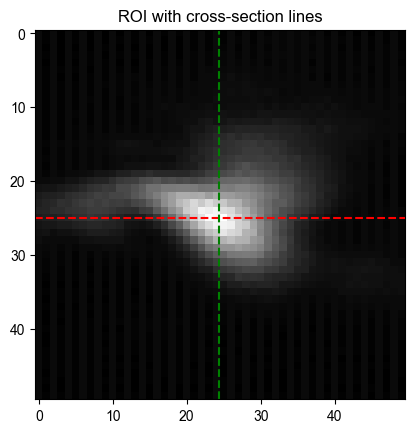

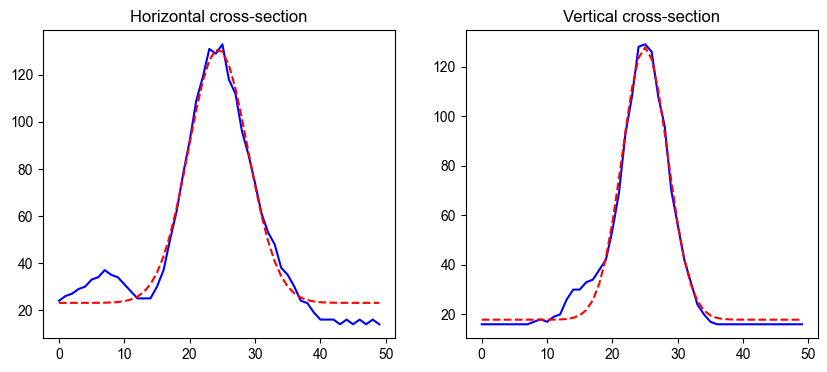

Processing im_101.3deg_frame_1.bmp...


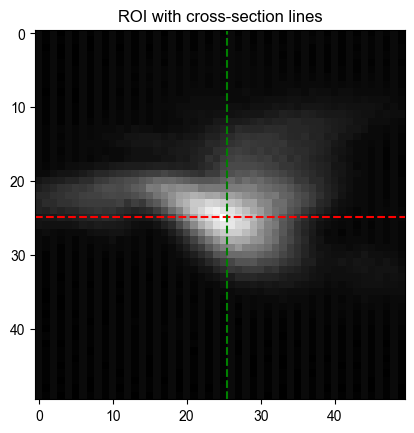

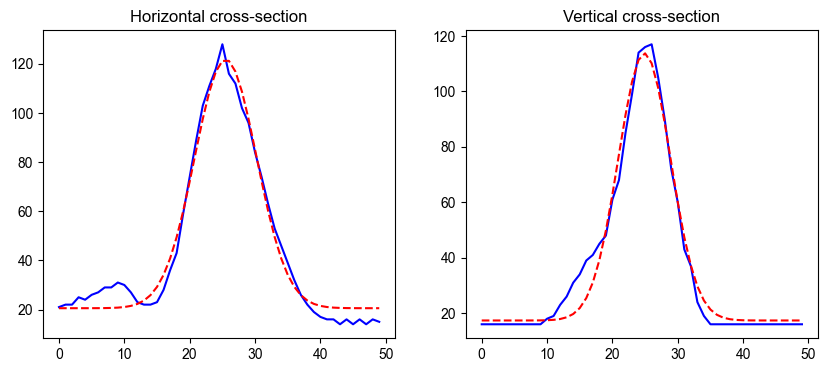

Processing im_108.5deg_frame_1.bmp...


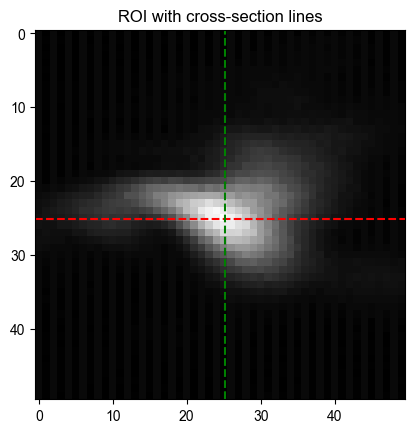

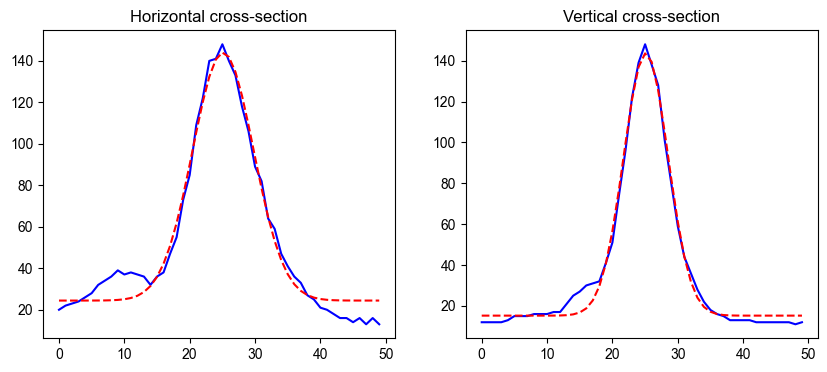

Processing im_114.9deg_frame_1.bmp...


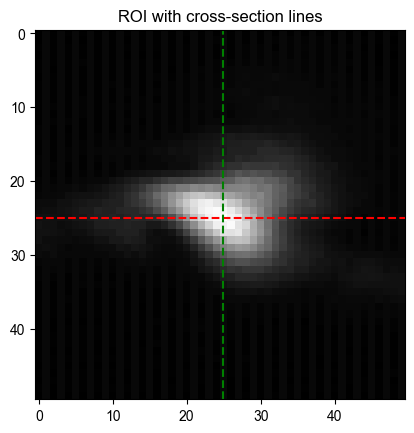

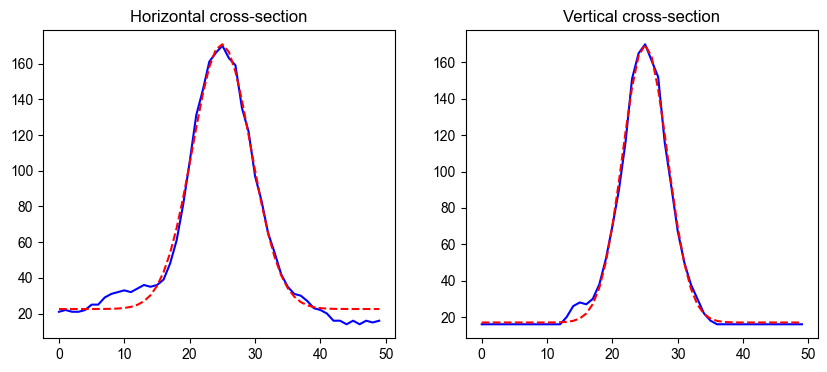

Processing im_111.8deg_frame_1.bmp...


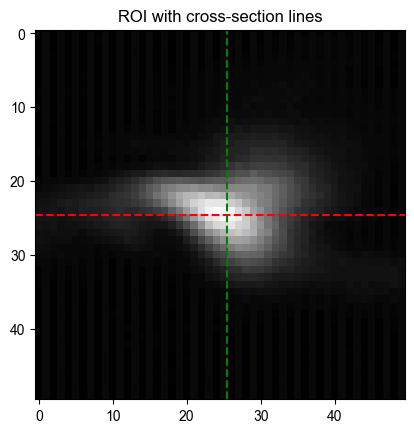

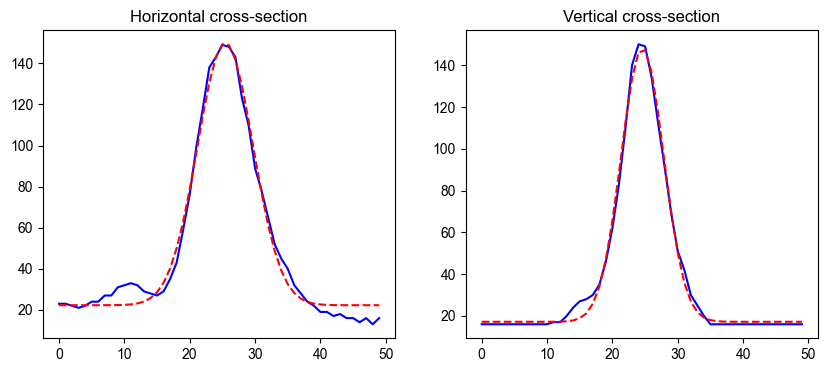

Processing im_121.0deg_frame_1.bmp...


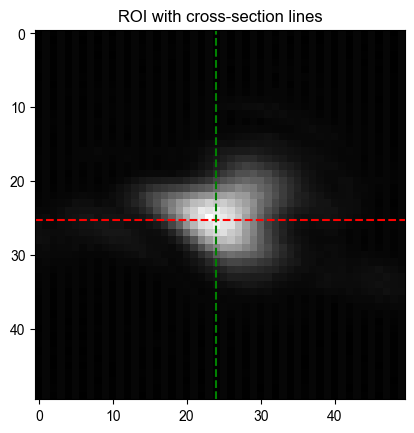

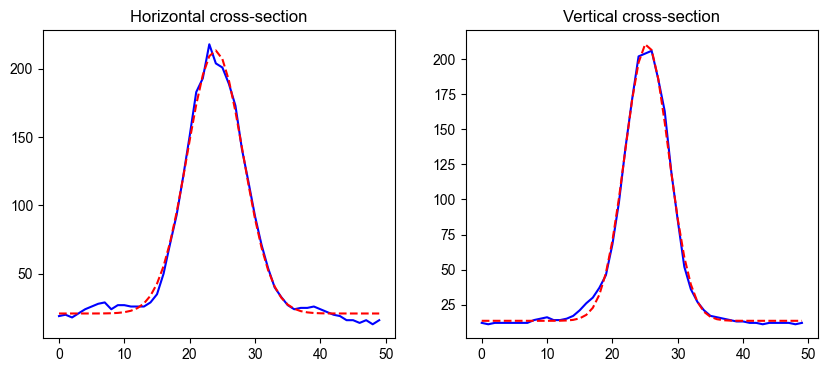

Processing im_118.0deg_frame_1.bmp...


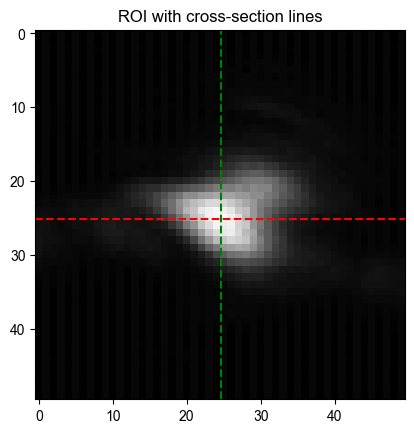

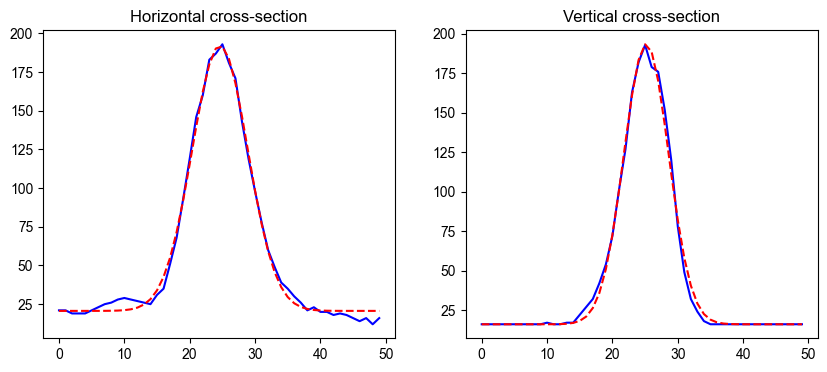

Processing im_123.9deg_frame_1.bmp...


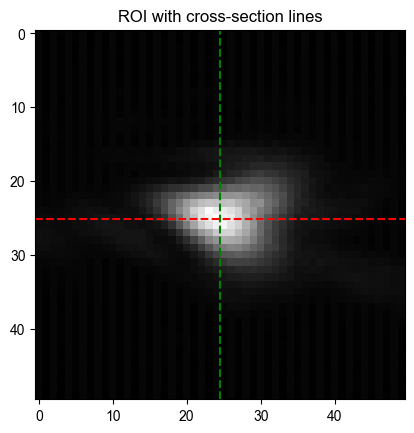

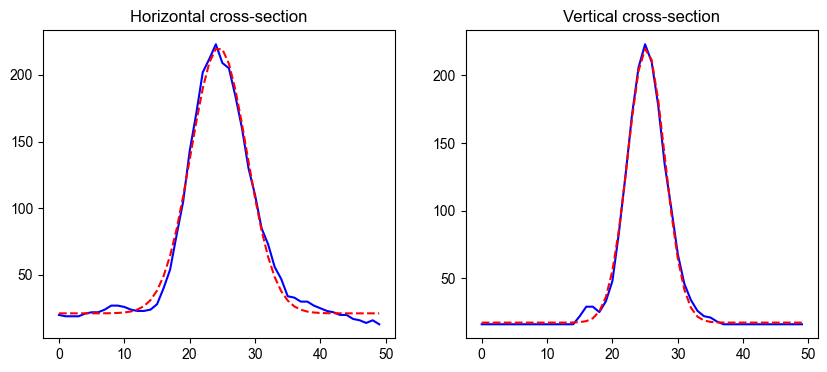

Processing im_129.4deg_frame_1.bmp...


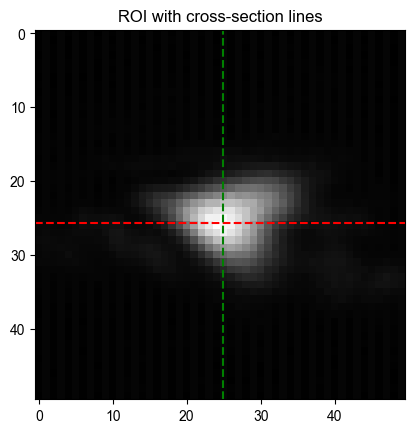

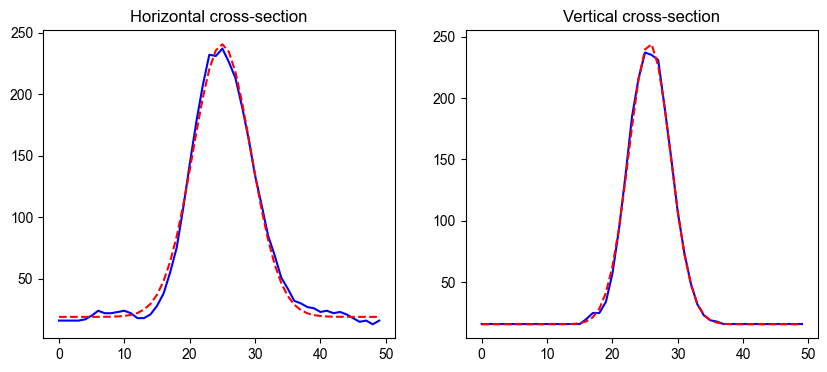

Processing im_126.7deg_frame_1.bmp...


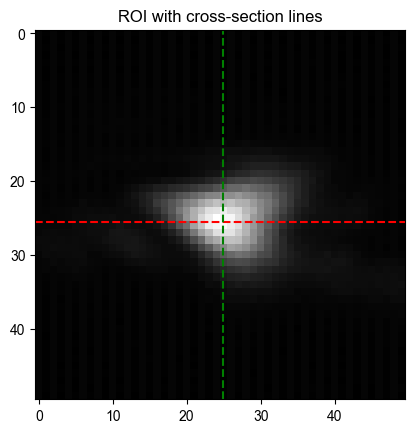

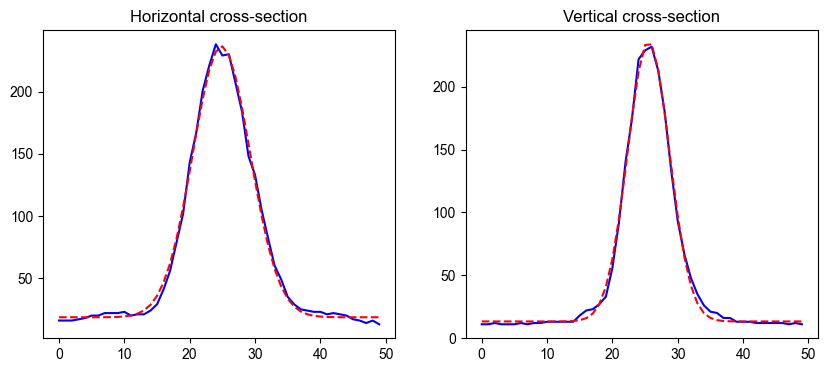

Processing im_137.5deg_frame_1.bmp...


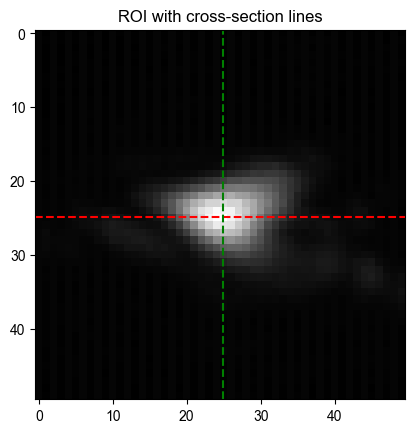

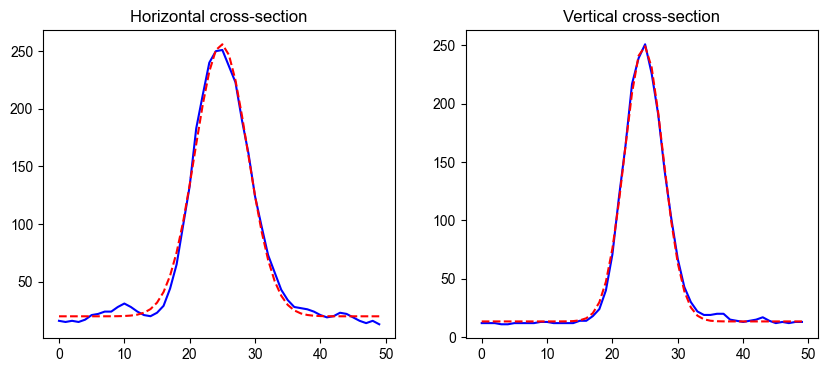

Processing im_134.9deg_frame_1.bmp...


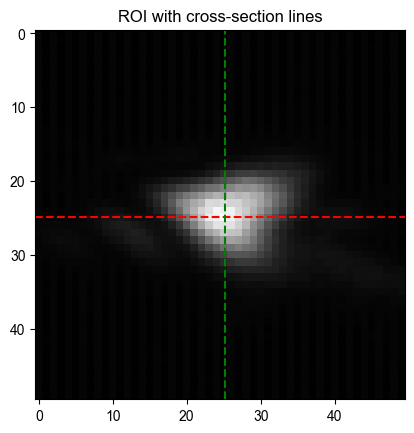

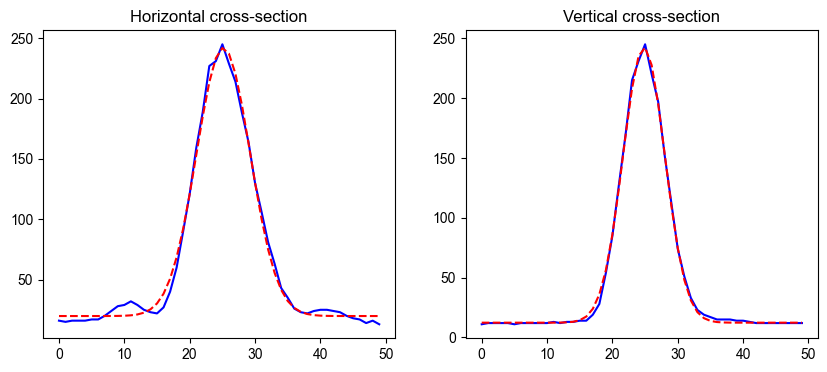

Processing im_132.2deg_frame_1.bmp...


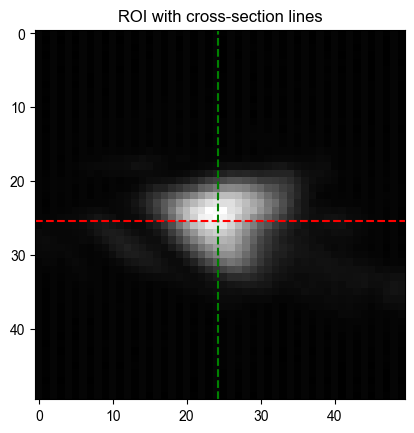

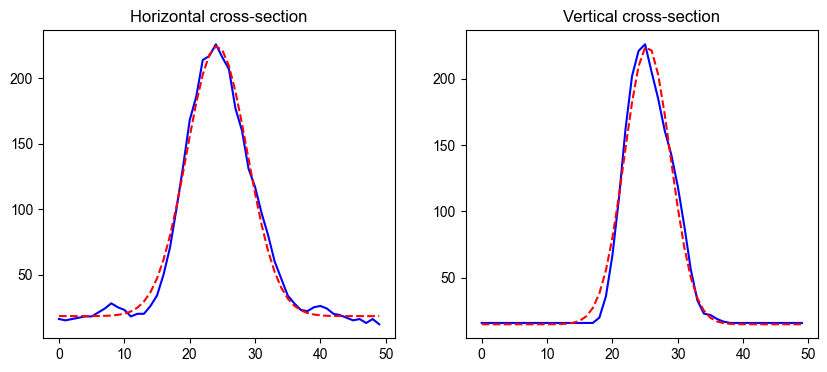

Processing im_142.8deg_frame_1.bmp...


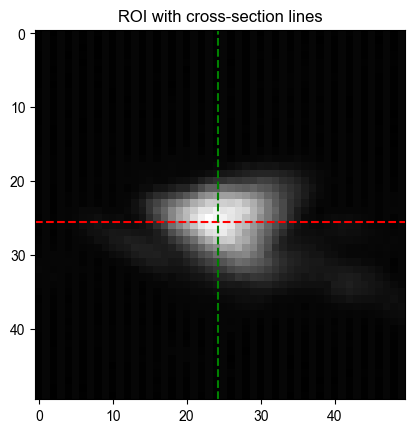

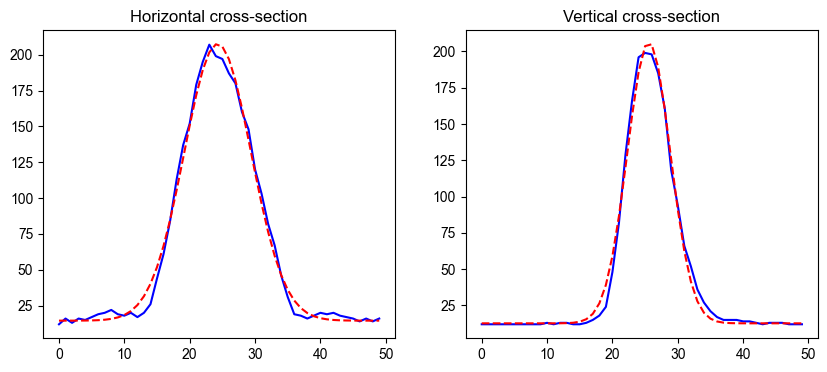

Processing im_140.2deg_frame_1.bmp...


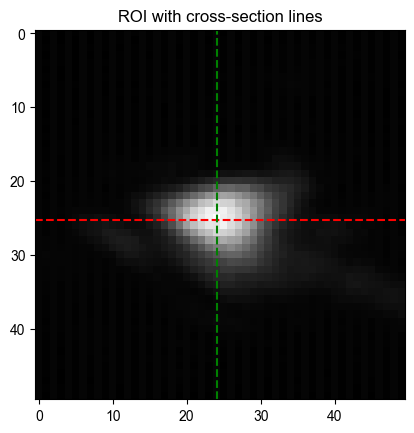

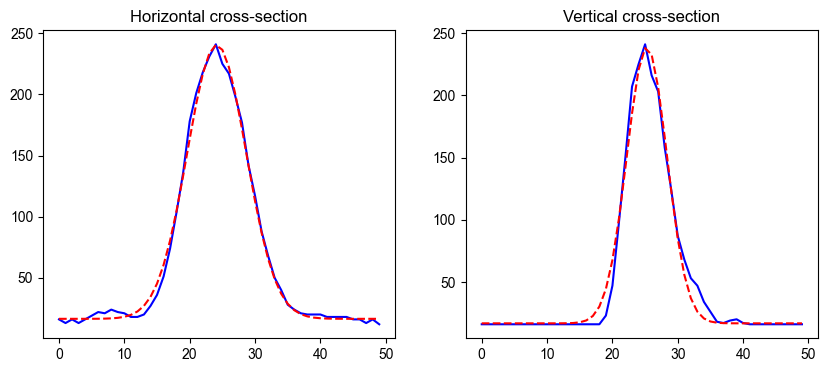

Processing im_150.6deg_frame_1.bmp...


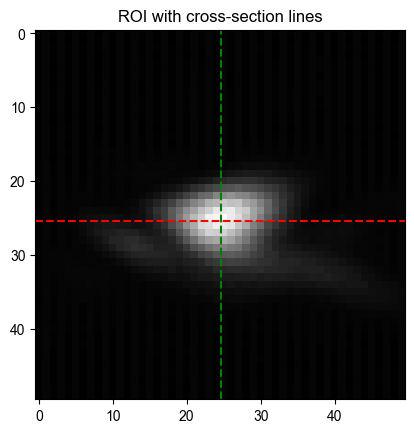

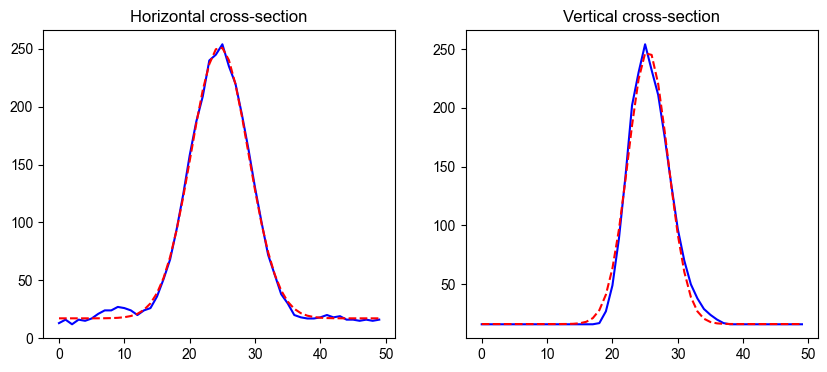

Processing im_148.0deg_frame_1.bmp...


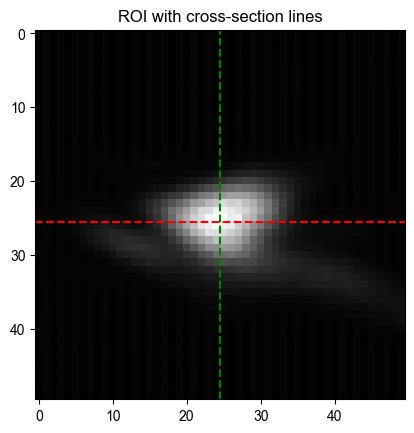

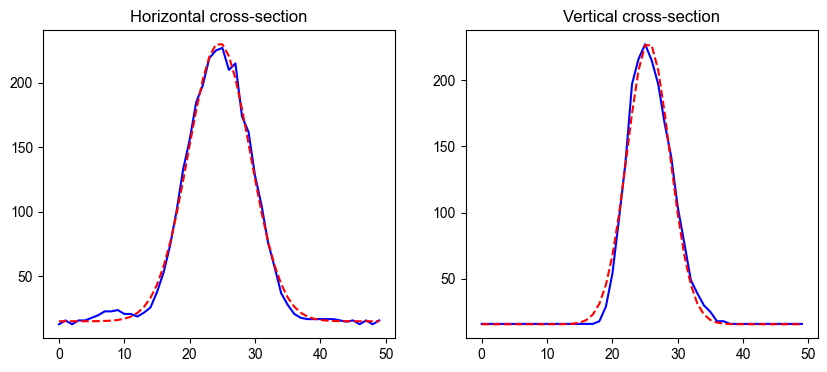

Processing im_145.4deg_frame_1.bmp...


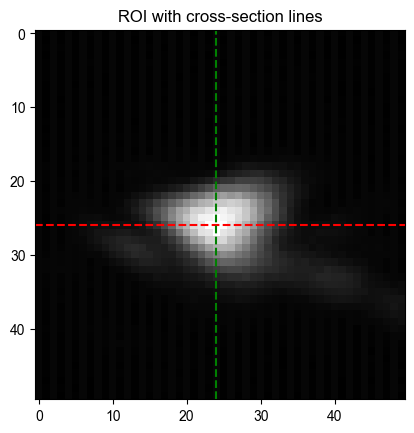

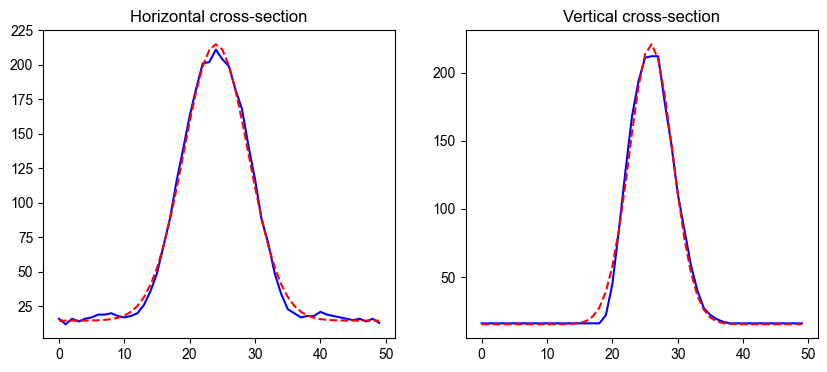

Processing im_158.5deg_frame_1.bmp...


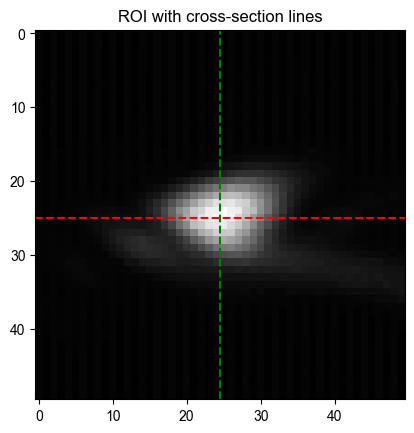

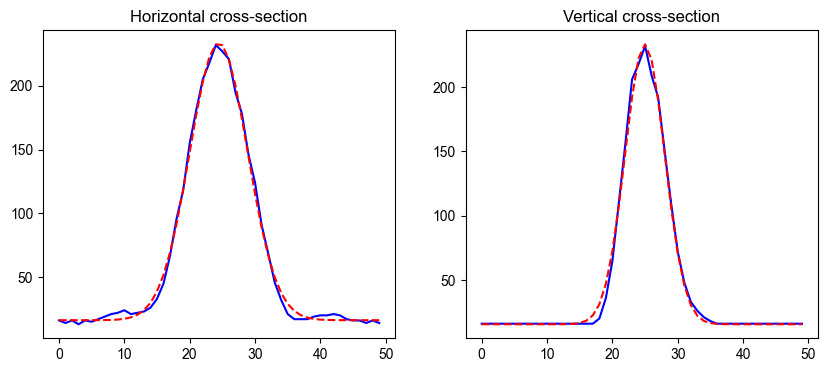

Processing im_155.8deg_frame_1.bmp...


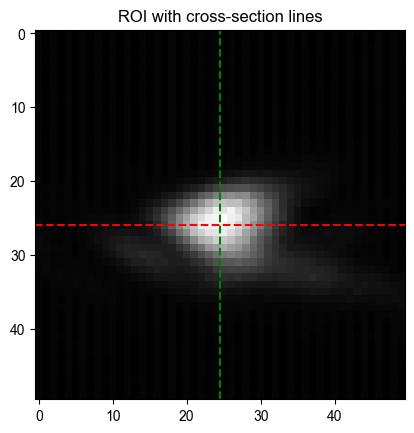

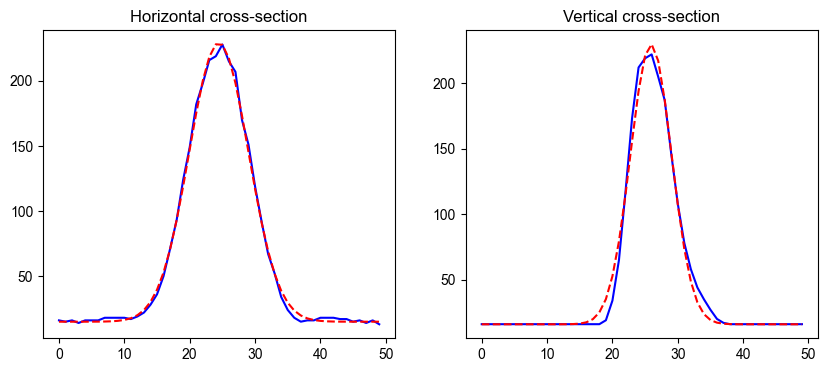

Processing im_153.2deg_frame_1.bmp...


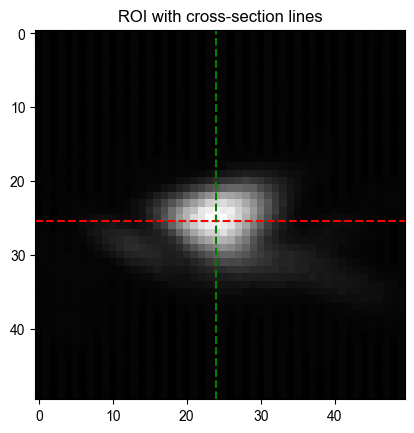

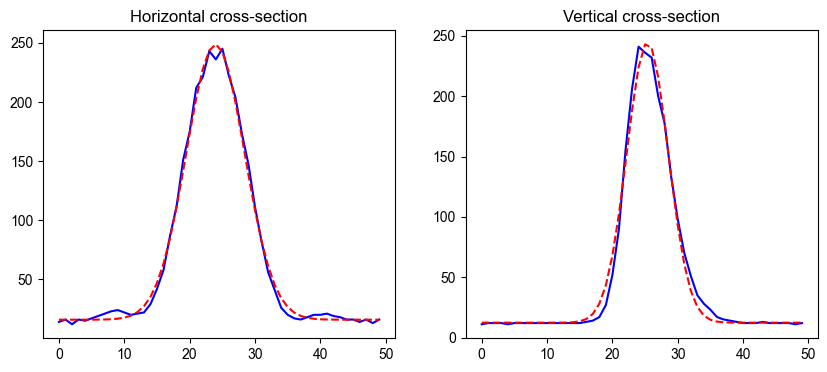

Processing im_163.8deg_frame_1.bmp...


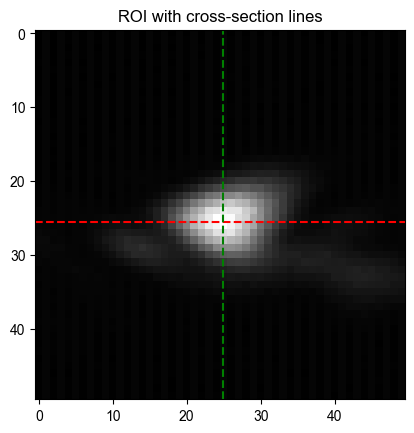

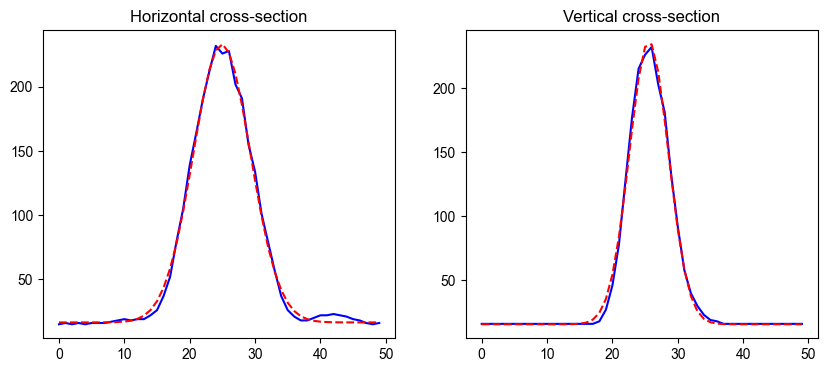

Processing im_161.1deg_frame_1.bmp...


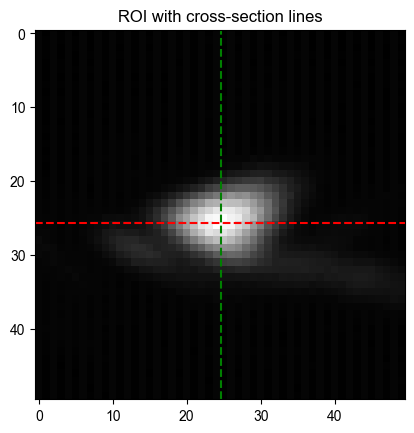

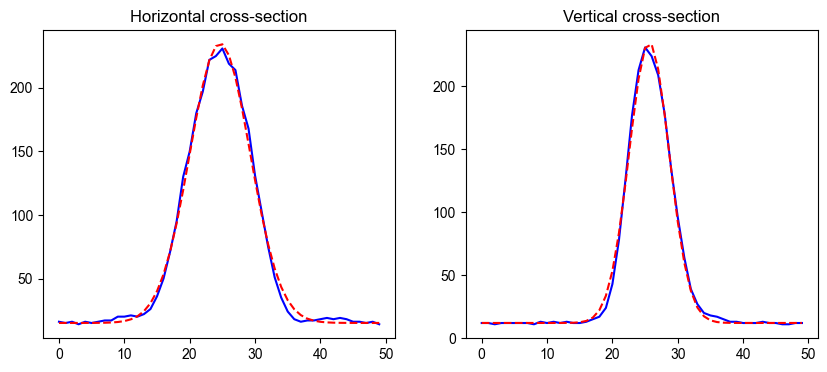

Processing im_166.6deg_frame_1.bmp...


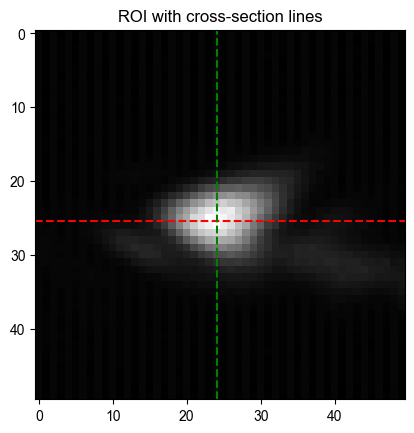

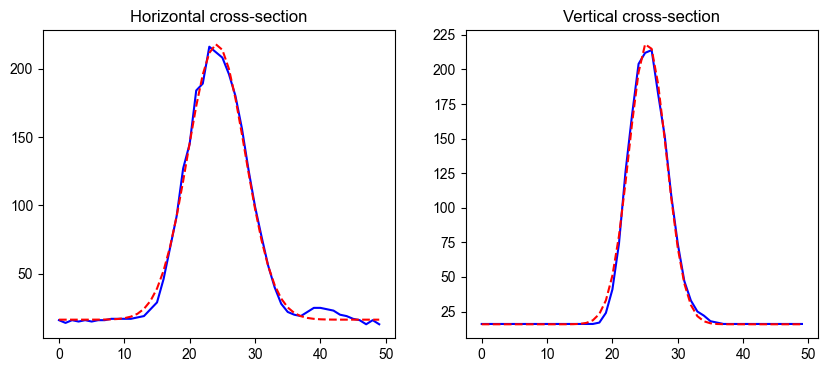

Processing im_175.0deg_frame_1.bmp...


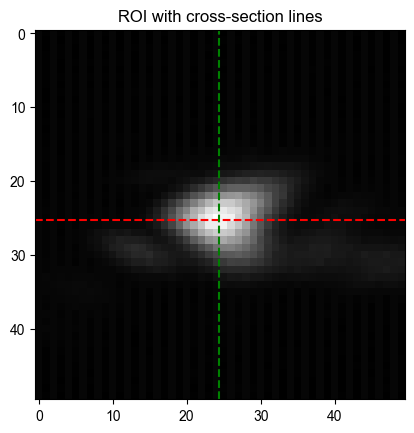

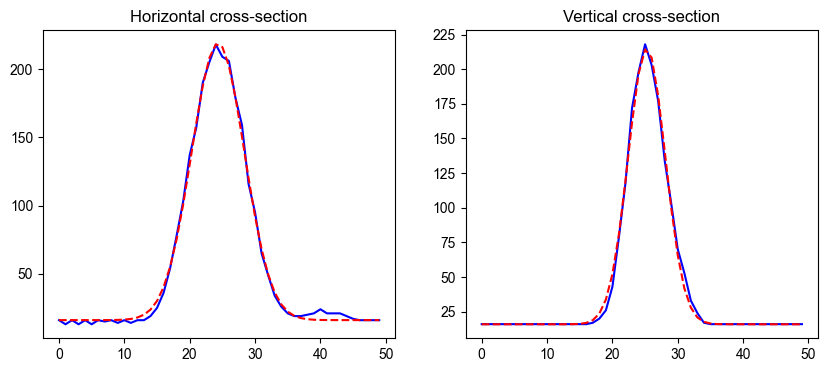

Processing im_172.1deg_frame_1.bmp...


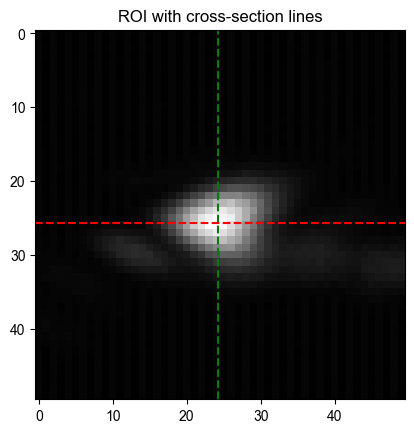

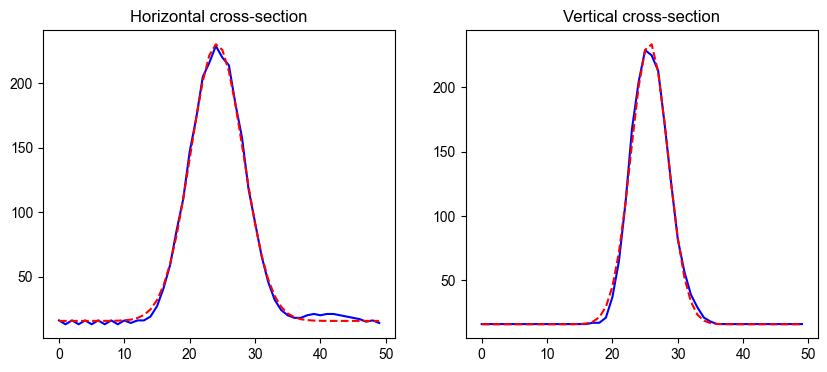

Processing im_169.3deg_frame_1.bmp...


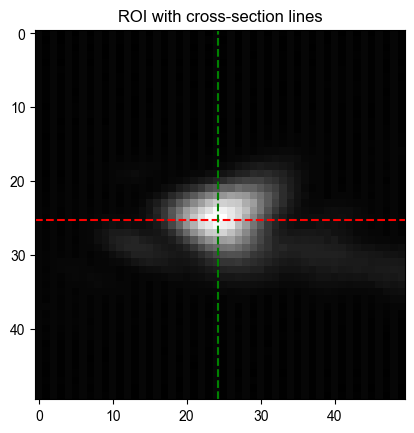

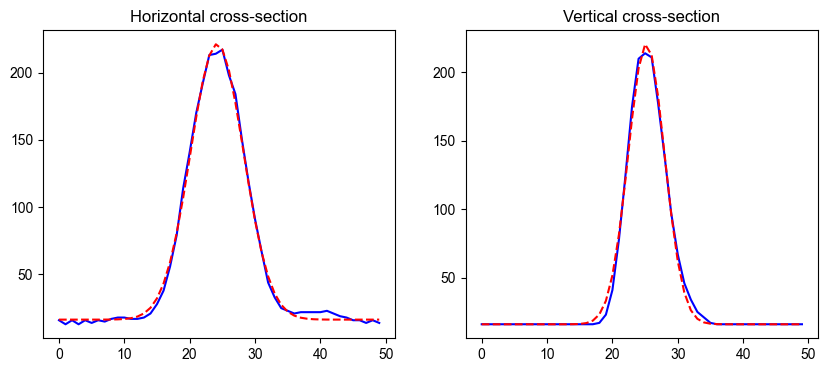

Processing im_184.2deg_frame_1.bmp...


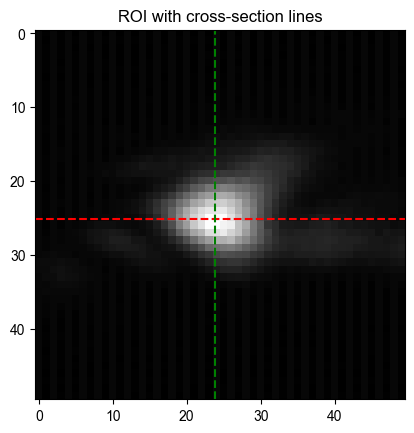

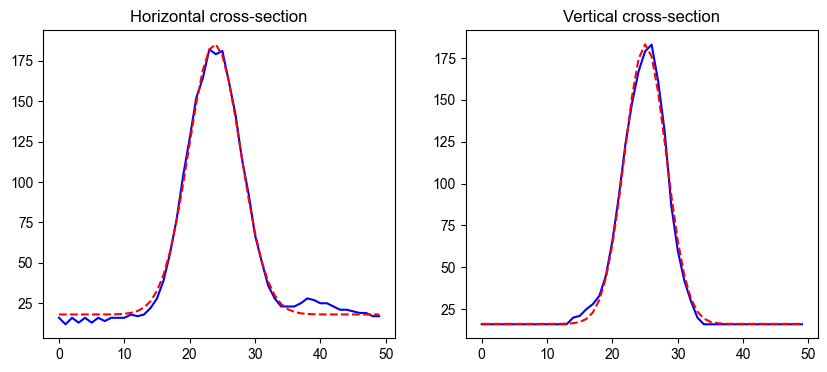

Processing im_181.1deg_frame_1.bmp...


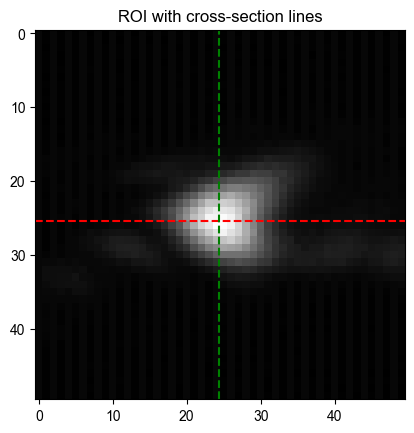

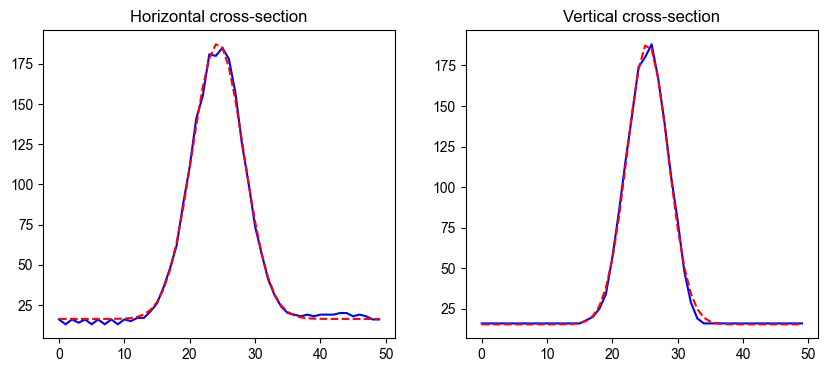

Processing im_178.0deg_frame_1.bmp...


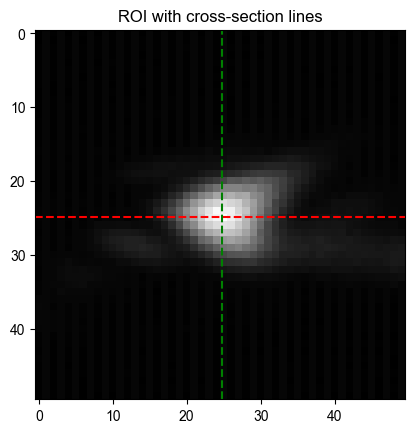

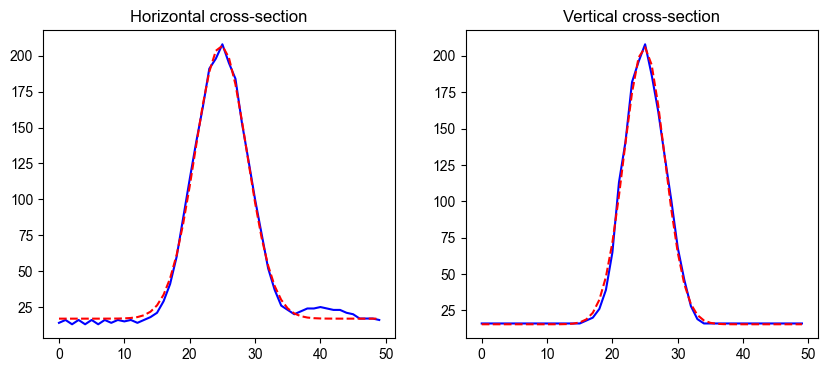

Processing im_191.0deg_frame_1.bmp...


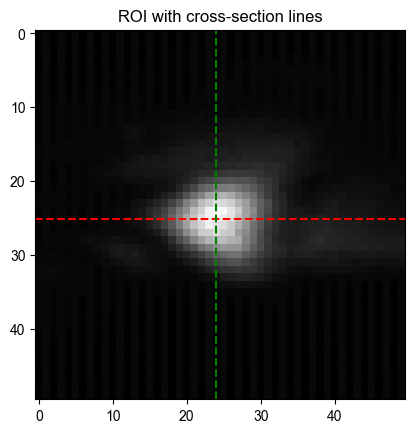

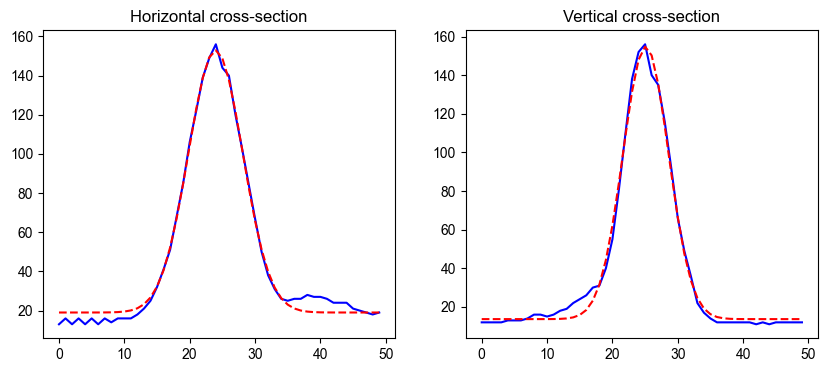

Processing im_187.5deg_frame_1.bmp...


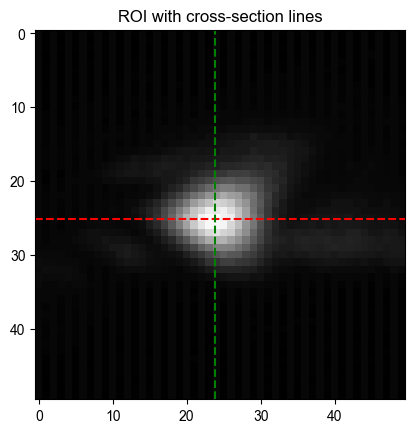

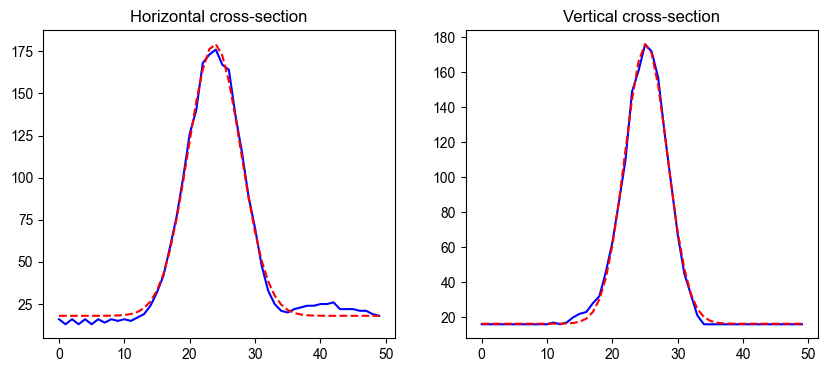

Processing im_202.9deg_frame_1.bmp...


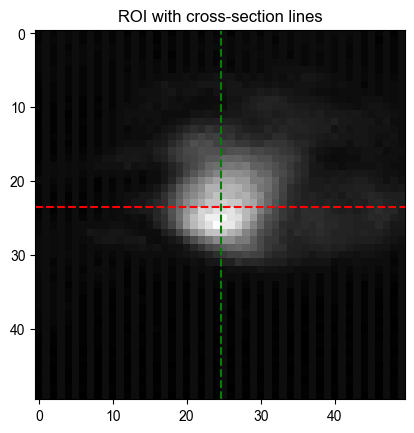

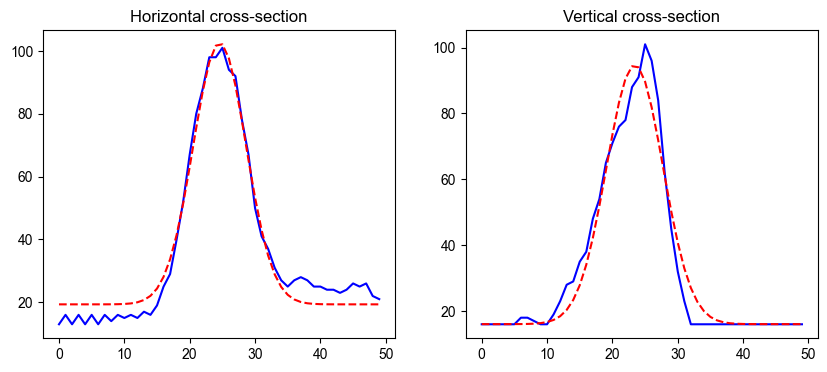

Processing im_198.6deg_frame_1.bmp...


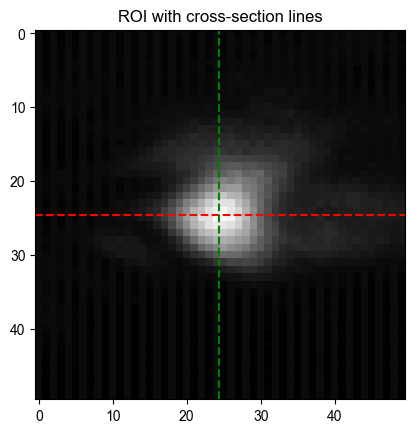

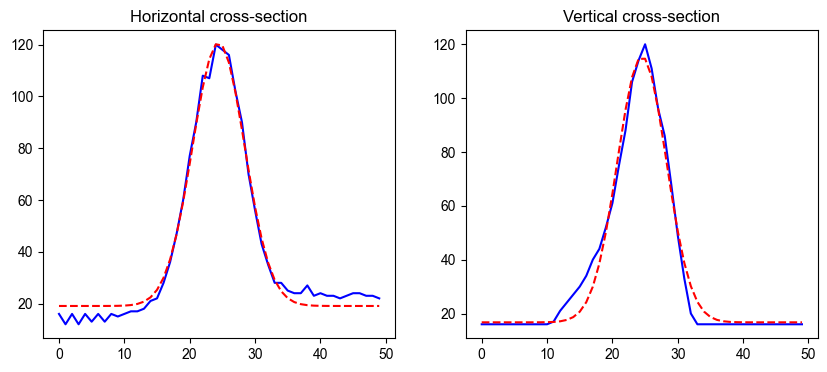

Processing im_194.7deg_frame_1.bmp...


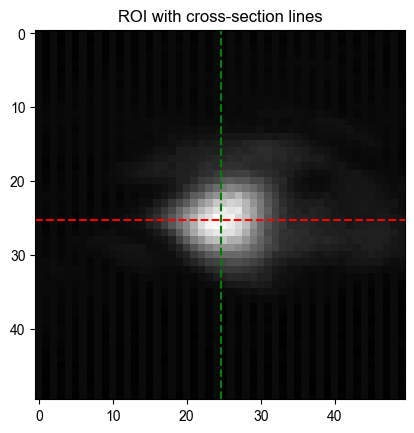

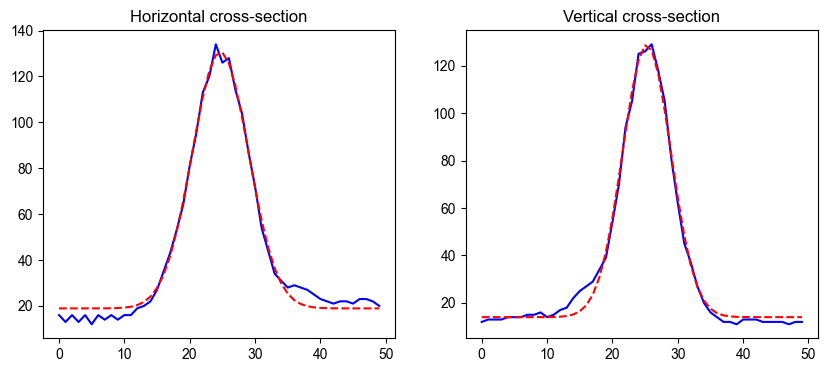

Processing im_213.4deg_frame_1.bmp...


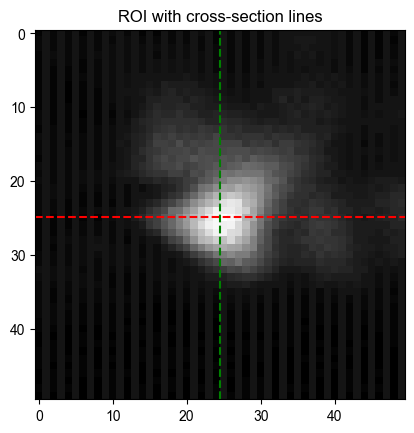

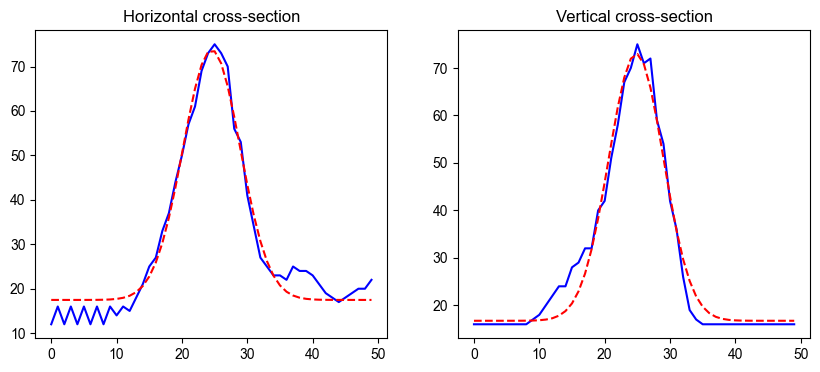

Processing im_207.7deg_frame_1.bmp...


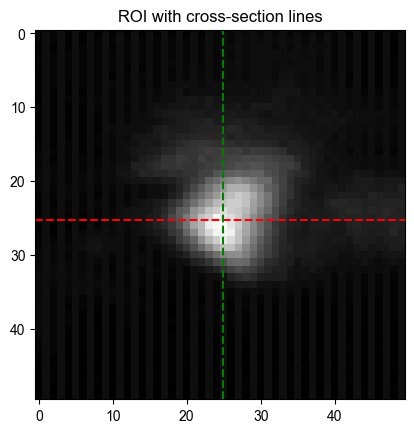

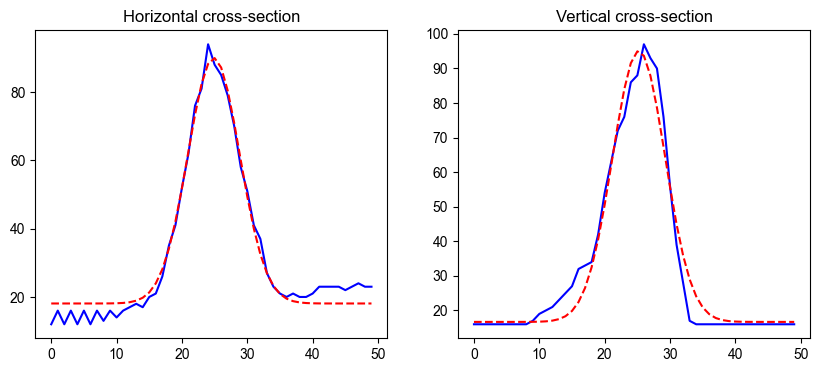

Processing im_238.0deg_frame_1.bmp...


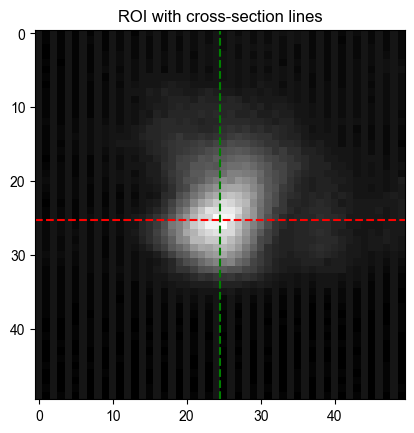

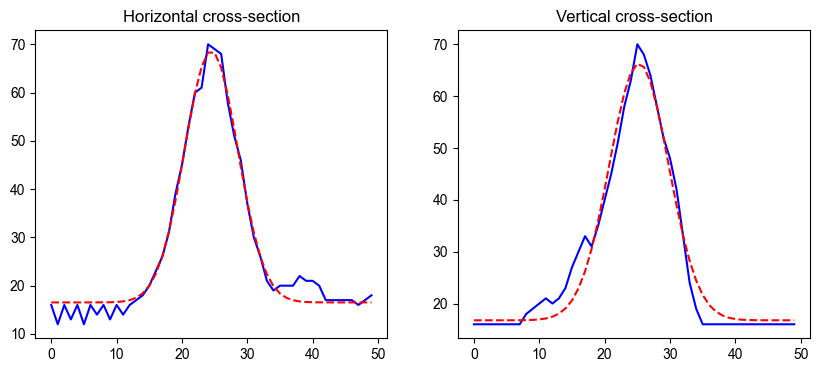

Processing im_220.7deg_frame_1.bmp...


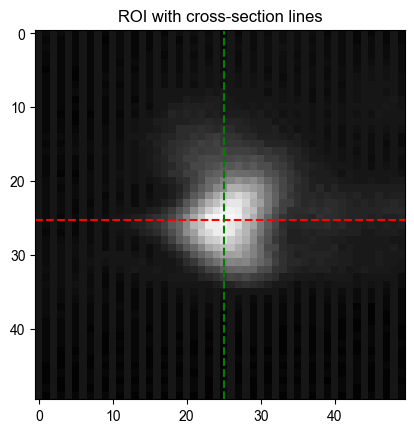

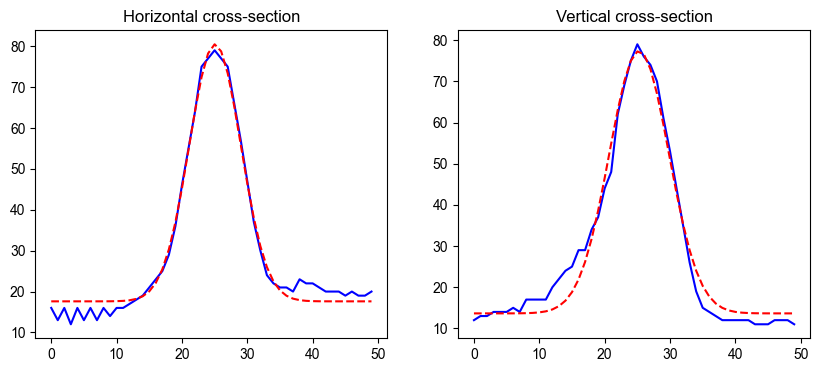

Processing im_82.6deg_frame_1.bmp...


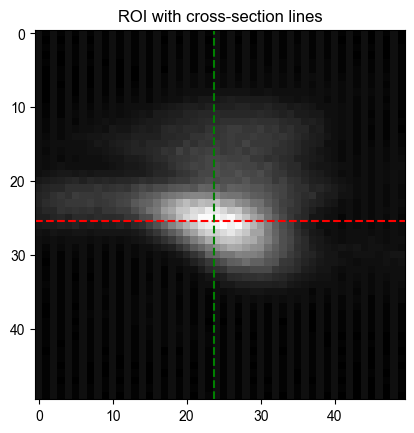

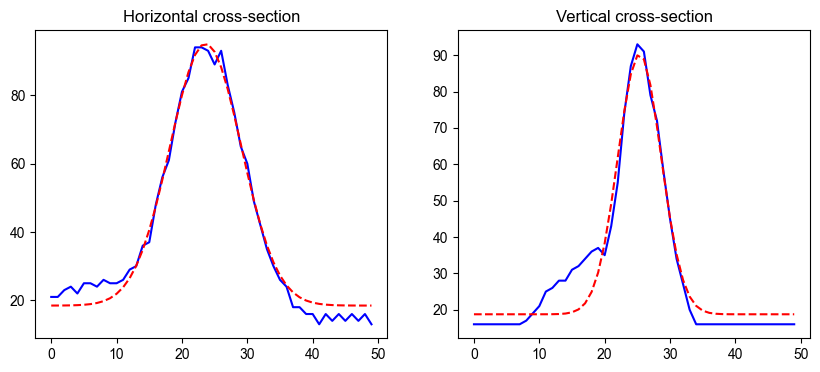

Processing im_75.3deg_frame_1.bmp...


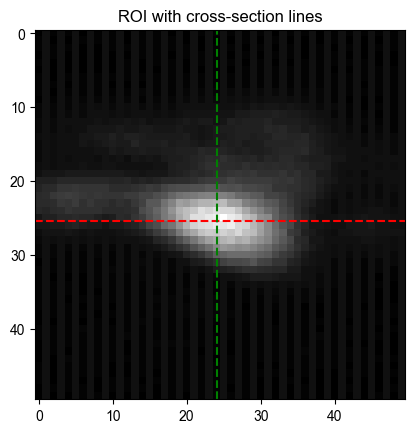

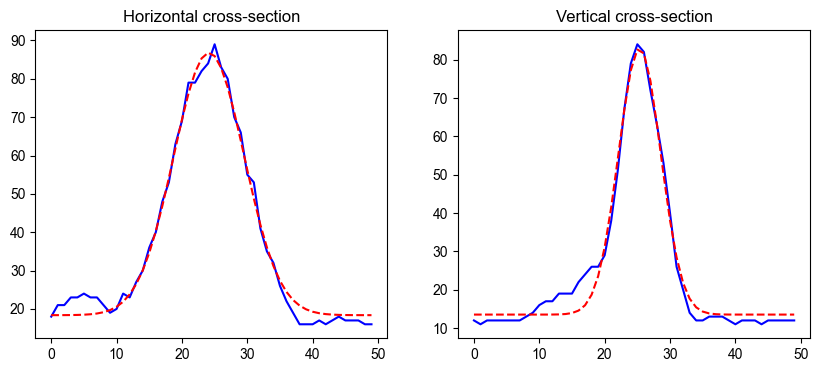

Processing im_58.0deg_frame_1.bmp...


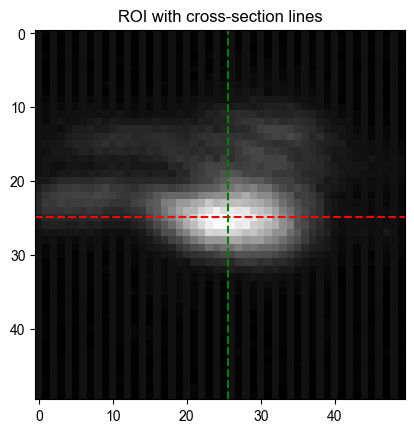

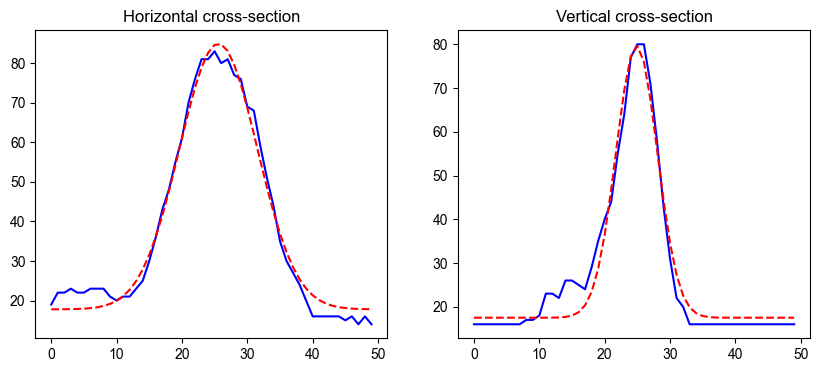

Processing im_93.1deg_frame_1.bmp...


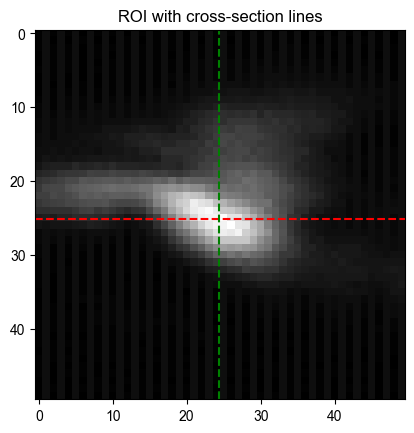

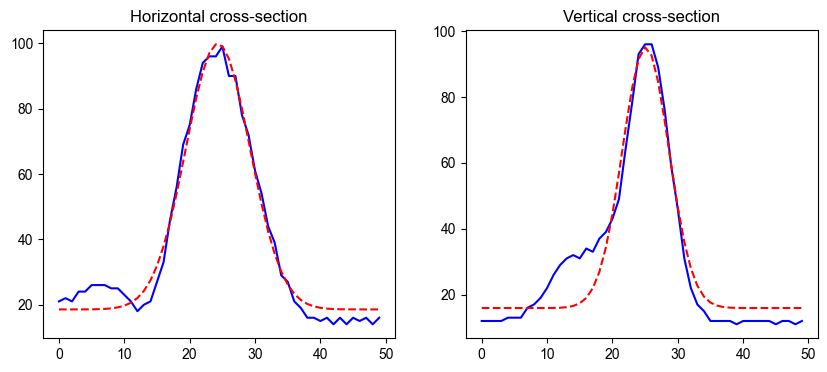

Processing im_88.3deg_frame_1.bmp...


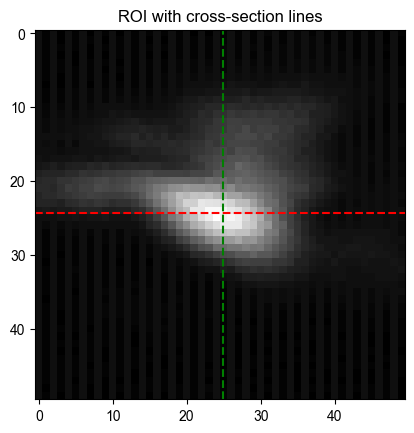

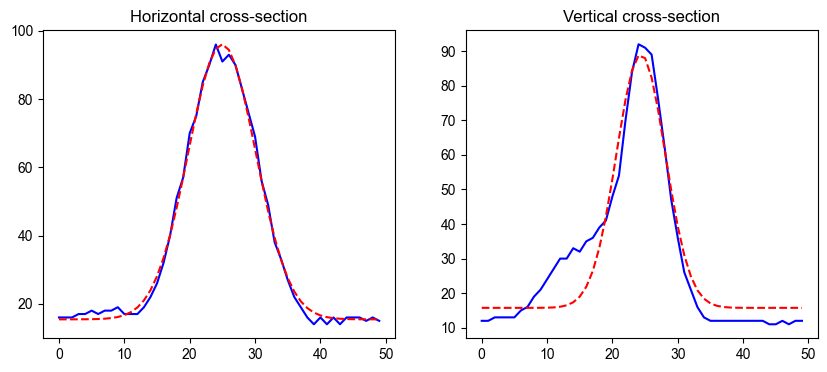

Processing im_97.4deg_frame_1.bmp...


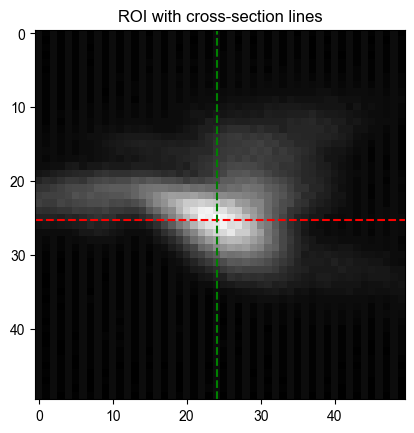

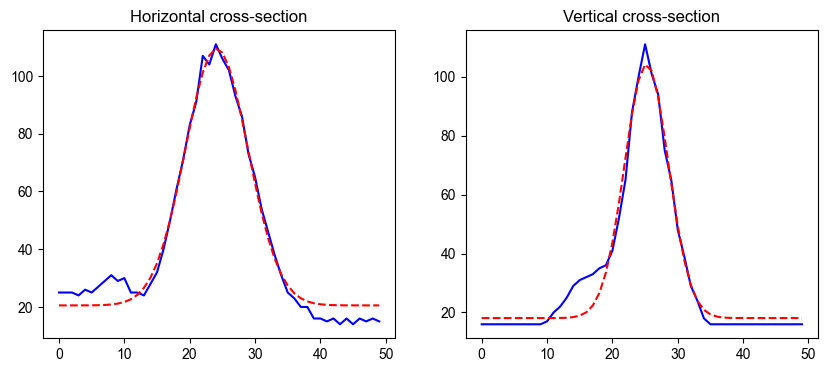

Processing complete. Results saved in G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 3\data\070125_100kHz_spot_data\fig3_spotdata_nworkup_090225


In [109]:
process_images(parent_dir, roi_size=50, threshold_frac=.75, angle=0, x1=0, x2=2592)

In [110]:
csv_path=os.path.join(parent_dir, 'results.csv')
save_path=os.path.join(parent_dir, 'summary.txt')
spot_analysis=analyze_fwhm(csv_path,save_path)

Average horizontal FWHM: 10.48 ± 0.21
Distance between furthest corrected horizontal centroids: 1374.90 ± 0.15
Spots: 131.22 ± 2.60


In [111]:
average_profiles_and_fit(parent_dir,roi=50)

Averaged profiles and Gaussian fits saved.


{'horizontal_fit_params': array([156.38224575,  24.48744053,   4.41478306,  18.342127  ]),
 'vertical_fit_params': array([157.71542052,  25.27147485,   3.22249879,  15.89184873])}

In [143]:
avg_h = pd.read_csv(os.path.join(parent_dir, "avg_horizontal_profile.csv"))
x_h, y_h = avg_h["x"].values, avg_h["intensity"].values

fit_h = pd.read_csv(os.path.join(parent_dir, "avg_horizontal_fit.csv"))
x_fit, y_fit = fit_h["x"].values, fit_h["fit_intensity"].values

In [148]:
pix2um_data_x=((2.2*x_h)-(2.2*max(x_h)/2))
y_h_cor=y_h-min(y_h)
y_fit_cor=y_fit-min(y_fit)

Plot saved as SVG to G:\Shared drives\Kerlin lab shared\Manuscripts\Reload Paper\Figures\Fig. 3\data\070125_100kHz_spot_data\fig3_spotdata_nworkup_090225\avg_horz_final.svg


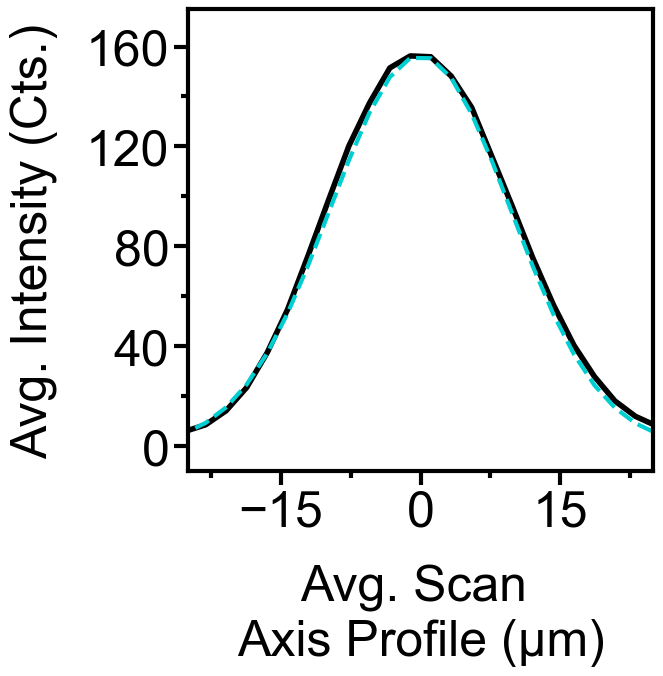

In [157]:
plot_xy(pix2um_data_x,y_h_cor,
            title=None,
            xlabel="Avg. Scan \nAxis Profile (μm)",
            ylabel="Avg. Intensity (Cts.)",
            x_min=-25,x_max=25, 
        y_min=-10, y_max=175,
            save_path=os.path.join(parent_dir, 'avg_horz_final.svg'),
fit_line=y_fit_cor,          
fit_color='darkturquoise',         
fit_linestyle='--',     
fit_linewidth=3,
        fig_width=6,
       fig_height=6)       

In [158]:
1374.90*2.2

3024.7800000000007